In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:,0]**2 + 0.5 * np.random.random(100)

In [3]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y
display(df)

,X,y
0,-0.125460,0.062935
1,0.450714,0.927635
2,0.231994,0.318642
3,0.098658,0.283486
4,-0.343981,0.808753
...,...,...
95,-0.006204,0.174720
96,0.022733,0.364528
97,-0.072459,0.464306
98,-0.474581,1.119224


Text(0.5, 1.0, 'X vs y')

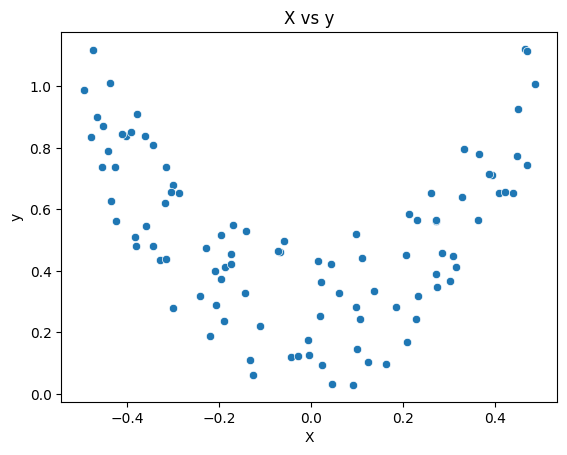

In [4]:
sns.scatterplot(x=df['X'], y=df['y'])
plt.title('X vs y')

In [5]:
# first model prediction
df['pred1'] = np.mean(df['y'])

In [6]:
# calculate residual
df['res1'] = df['y'] - df['pred1']

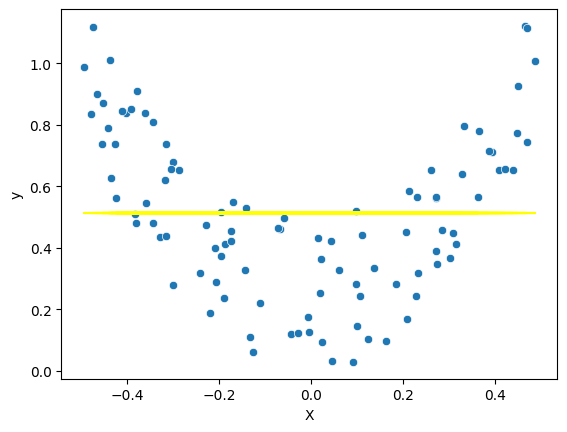

In [7]:
# plotting prediction 
sns.scatterplot(x=df['X'], y=df['y'])
plt.plot(df['X'], df['pred1'], c = 'yellow')

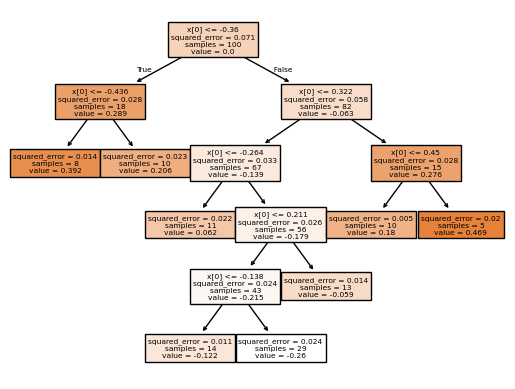

In [8]:
# now plotting decision tree 

tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(df['X'].values.reshape(100,1), df['res1'].values)
plot_tree(tree1, filled=True)
plt.show()

In [9]:
# predicting model2

X_test = np.linspace(-0.5, 0.5,500)
y_pred = df['pred1'].mean() +  tree1.predict(X_test.reshape(500,1))

<Axes: xlabel='X', ylabel='y'>

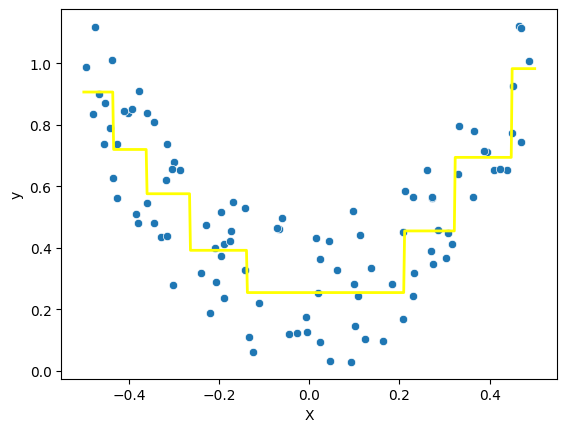

In [10]:
# ploting

plt.plot(X_test, y_pred, linewidth=2, c='yellow')
sns.scatterplot(x=df['X'], y=df['y'])

In [11]:
# storing in df 

df['pred2'] = df['pred1'].mean() + tree1.predict(df['X'].values.reshape(100,1))
display(df)

,X,y,pred1,res1,pred2
0,-0.125460,0.062935,0.514428,-0.451493,0.254657
1,0.450714,0.927635,0.514428,0.413207,0.982974
2,0.231994,0.318642,0.514428,-0.195787,0.455130
3,0.098658,0.283486,0.514428,-0.230942,0.254657
4,-0.343981,0.808753,0.514428,0.294324,0.576095
...,...,...,...,...,...
95,-0.006204,0.174720,0.514428,-0.339708,0.254657
96,0.022733,0.364528,0.514428,-0.149900,0.254657
97,-0.072459,0.464306,0.514428,-0.050122,0.254657
98,-0.474581,1.119224,0.514428,0.604796,0.906892


In [12]:
# calculate residual_2

df['res2'] = df['y'] - df['pred2']

In [13]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1), df['res2'].values)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,8
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [14]:
y_pred = df['pred2'].mean() + sum(regressor.predict(X_test.reshape(-1, 1)) for regressor in [tree1, tree2])

<Axes: xlabel='X', ylabel='y'>

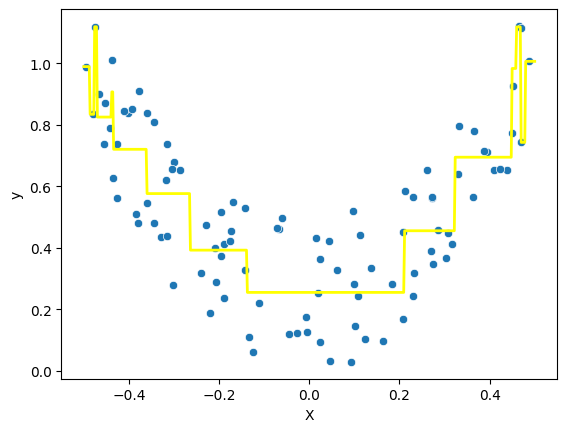

In [15]:
# ploting

plt.plot(X_test, y_pred, linewidth=2, c='yellow')
sns.scatterplot(x=df['X'], y=df['y'])

### recursion function to do uppre task autometic if we given some parameter

In [16]:
def gradient_boost(X,y, number, lr, count=1, regs=[ ], foo=None) :

    if number == 0:
        return
    else:
    # do gradient boosting
    
        if count > 1:
            y = y - regs [-1].predict (X)
        else:
            foo = y
        
        tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
        tree_reg.fit(X, y)
        
        regs.append(tree_reg)
        
        x1 = np.linspace(-0.5, 0.5, 500)
        y_pred = sum(lr * regressor. predict(x1.reshape(-1, 1)) for regressor in regs)
        print(number)
        plt.figure()
        plt.plot(x1, y_pred, linewidth=2)
        plt.plot(X[:, 0], foo,"r.")
        plt.show()
        
        gradient_boost(X,y, number-1,lr, count+1,regs,foo=foo)

5


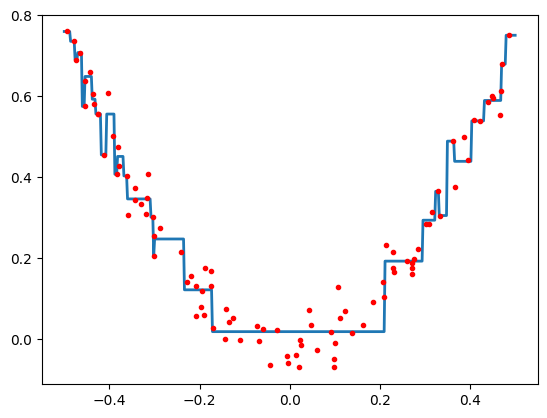

4


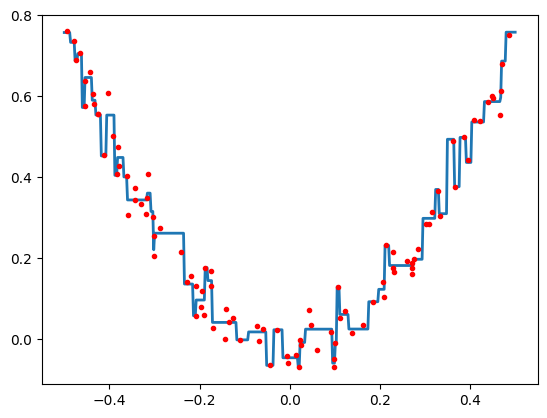

3


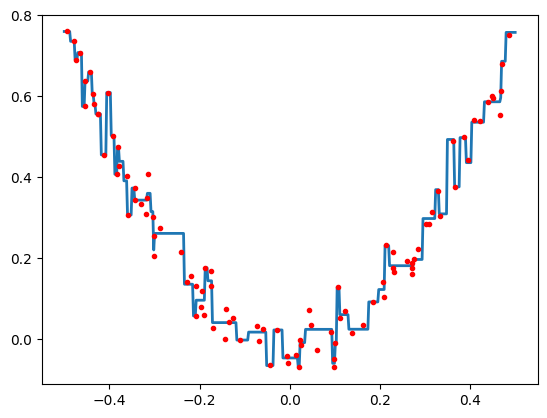

2


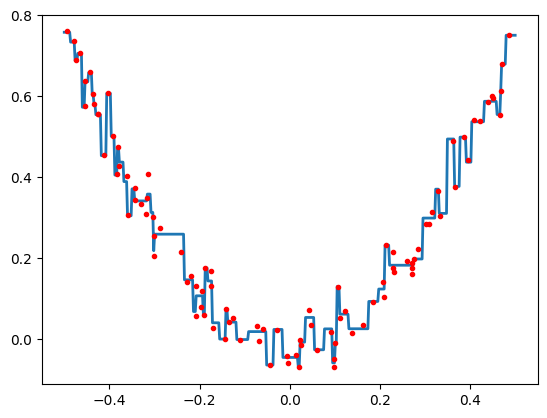

1


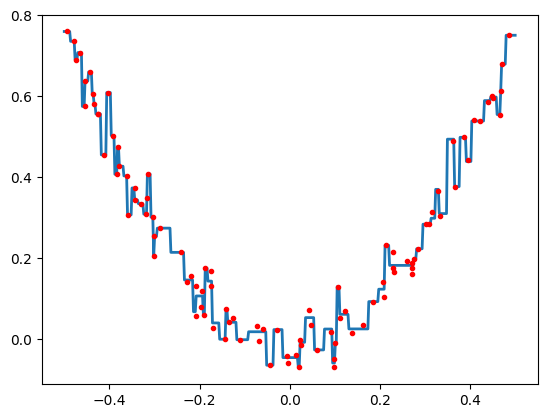

In [17]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0] ** 2 + 0.05 * np.random.randn(100)
gradient_boost(X,y,5,lr=1)